# State-Level Sales Analysis

## Detailed Performance Breakdown

Now let's dig into what's actually driving sales across different states.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../AusApparalSales4thQrt2020.csv')

for col in ['Time', 'State', 'Group']:
    df[col] = df[col].str.strip()

state_revenue = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
state_units = df.groupby('State')['Unit'].sum().sort_values(ascending=False)

print("Revenue by State (Highest to Lowest):")
print(state_revenue)
print(f"\nUnits Sold by State:")
print(state_units)

Revenue by State (Highest to Lowest):
State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

Units Sold by State:
State
VIC    42226
NSW    29988
SA     23543
QLD    13367
TAS     9104
NT      9032
WA      8861
Name: Unit, dtype: int64


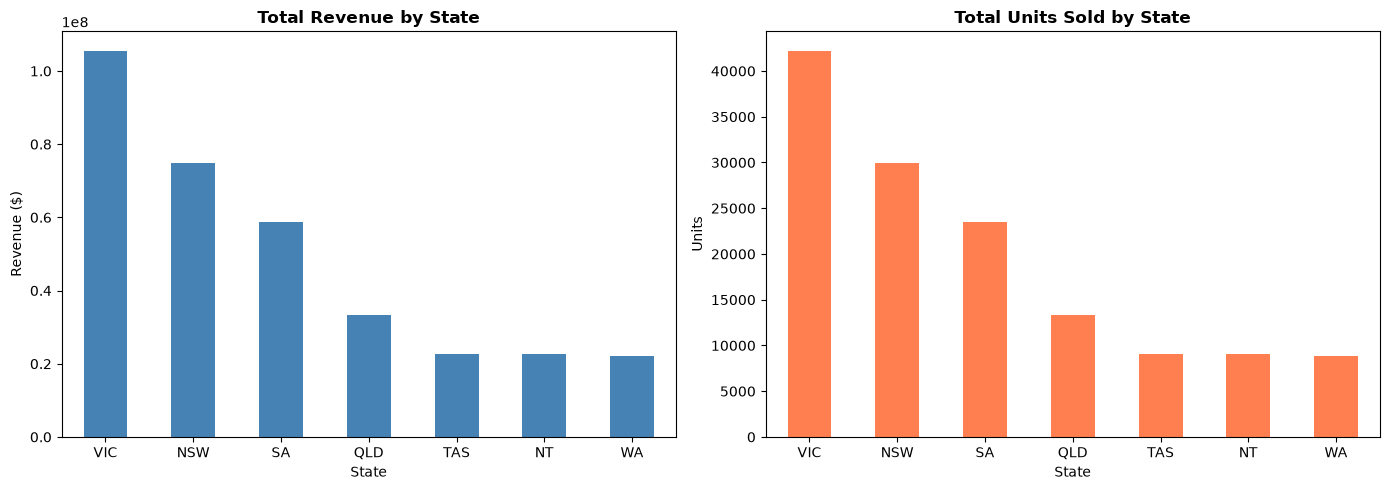

Chart saved to outputs/visualizations/


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

state_revenue.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total Revenue by State', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_xlabel('State')
axes[0].tick_params(axis='x', rotation=0)

state_units.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Total Units Sold by State', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Units')
axes[1].set_xlabel('State')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/visualizations/revenue_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/visualizations/")

In [3]:
state_stats = df.groupby('State').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Unit': ['sum', 'mean']
}).round(2)

state_stats.columns = ['Total Revenue', 'Avg Transaction', 'Transaction Count', 
                       'Total Units', 'Avg Units per Transaction']

print(state_stats)

       Total Revenue  Avg Transaction  Transaction Count  Total Units  \
State                                                                   
NSW         74970000         69416.67               1080        29988   
NT          22580000         20907.41               1080         9032   
QLD         33417500         30942.13               1080        13367   
SA          58857500         54497.69               1080        23543   
TAS         22760000         21074.07               1080         9104   
VIC        105565000         97745.37               1080        42226   
WA          22152500         20511.57               1080         8861   

       Avg Units per Transaction  
State                             
NSW                        27.77  
NT                          8.36  
QLD                        12.38  
SA                         21.80  
TAS                         8.43  
VIC                        39.10  
WA                          8.20  


## Demographic Performance by State

Which customer groups are driving sales in each region?

In [4]:
demo_by_state = df.groupby(['State', 'Group'])['Sales'].sum().unstack(fill_value=0)
print("Revenue by State and Demographic Group:")
print(demo_by_state)
print(f"\nTotal: {demo_by_state.sum().sum()}")

Revenue by State and Demographic Group:
Group      Kids       Men   Seniors     Women
State                                        
NSW    18587500  19022500  18187500  19172500
NT      5700000   5762500   5465000   5652500
QLD     8510000   8392500   8190000   8325000
SA     14515000  14655000  14717500  14970000
TAS     5775000   5757500   5650000   5577500
VIC    26360000  26407500  26315000  26482500
WA      5625000   5752500   5512500   5262500

Total: 340302500


In [5]:
demo_percentage = demo_by_state.div(demo_by_state.sum(axis=1), axis=0) * 100
print("\nDemographic Mix as % of State Revenue:")
print(demo_percentage.round(1))


Demographic Mix as % of State Revenue:
Group  Kids   Men  Seniors  Women
State                            
NSW    24.8  25.4     24.3   25.6
NT     25.2  25.5     24.2   25.0
QLD    25.5  25.1     24.5   24.9
SA     24.7  24.9     25.0   25.4
TAS    25.4  25.3     24.8   24.5
VIC    25.0  25.0     24.9   25.1
WA     25.4  26.0     24.9   23.8


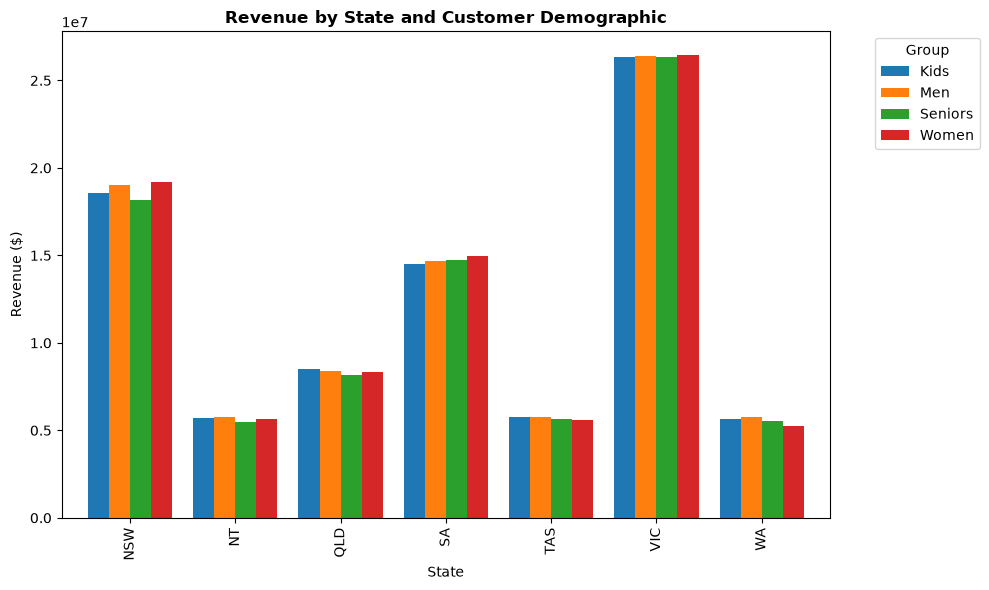

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
demo_by_state.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Revenue by State and Customer Demographic', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('State')
ax.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/visualizations/demographic_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

## Time-of-Day Analysis

Do sales patterns differ by time period across states?

In [7]:
time_by_state = df.groupby(['State', 'Time'])['Sales'].sum().unstack(fill_value=0)
print("Revenue by State and Time Period:")
print(time_by_state)

overall_time = df.groupby('Time')['Sales'].sum().sort_values(ascending=False)
print(f"\nOverall Revenue by Time Period:")
print(overall_time)

Revenue by State and Time Period:
Time   Afternoon   Evening   Morning
State                               
NSW     25110000  24712500  25147500
NT       7510000   7627500   7442500
QLD     11347500  10632500  11437500
SA      20025000  19367500  19465000
TAS      7670000   7565000   7525000
VIC     35062500  34880000  35622500
WA       7282500   7302500   7567500

Overall Revenue by Time Period:
Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64


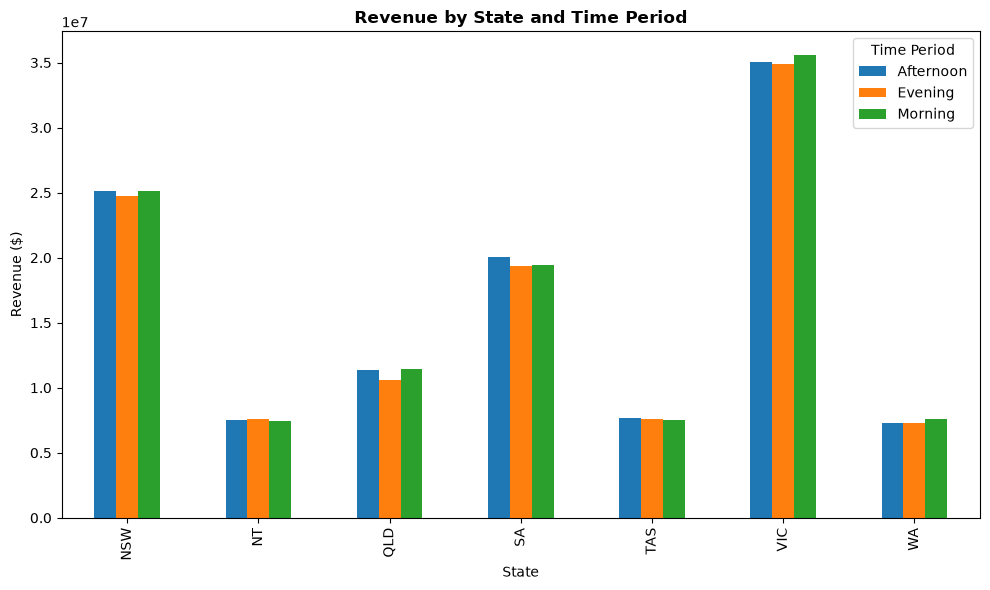

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
time_by_state.plot(kind='bar', ax=ax)
ax.set_title('Revenue by State and Time Period', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('State')
ax.legend(title='Time Period')
plt.tight_layout()
plt.savefig('../outputs/visualizations/time_period_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

## Top Performers vs Lower Performers

Let's categorize and compare performance tiers.

In [9]:
top_3_states = state_revenue.head(3)
bottom_2_states = state_revenue.tail(2)

print("Top Performing States:")
for state, revenue in top_3_states.items():
    print(f"  {state}: ${revenue:,.0f}")

print(f"\nStates Requiring Growth Programs:")
for state, revenue in bottom_2_states.items():
    print(f"  {state}: ${revenue:,.0f}")

total = state_revenue.sum()
top_3_pct = (top_3_states.sum() / total) * 100
bottom_2_pct = (bottom_2_states.sum() / total) * 100

print(f"\nTop 3 states account for {top_3_pct:.1f}% of total revenue")
print(f"Bottom 2 states account for {bottom_2_pct:.1f}% of total revenue")

Top Performing States:
  VIC: $105,565,000
  NSW: $74,970,000
  SA: $58,857,500

States Requiring Growth Programs:
  NT: $22,580,000
  WA: $22,152,500

Top 3 states account for 70.3% of total revenue
Bottom 2 states account for 13.1% of total revenue


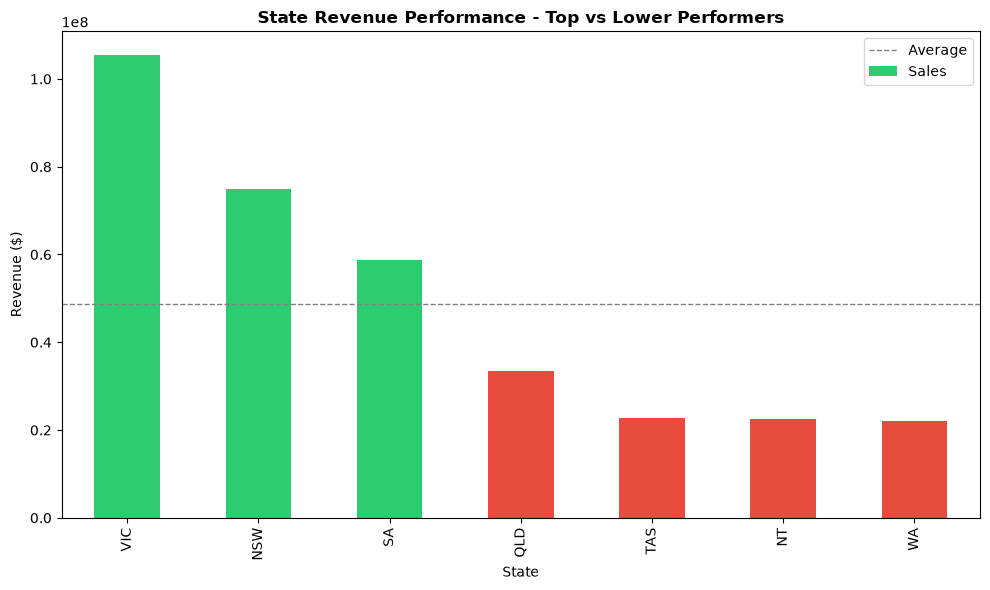

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if x in top_3_states.index else '#e74c3c' for x in state_revenue.index]
state_revenue.plot(kind='bar', ax=ax, color=colors)
ax.set_title('State Revenue Performance - Top vs Lower Performers', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('State')
ax.axhline(y=state_revenue.mean(), color='gray', linestyle='--', linewidth=1, label='Average')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/visualizations/performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()